# Commune ML — Rhône department
Three models built on the same feature matrix:
1. **Vulnerability score** — PCA-derived composite index (unsupervised)
2. **Abstention regression** — predict `pct_abs_ins` from socioeconomic + security features
3. **Dominant nuance classification** — predict winning political family per commune

All three share the same feature engineering pipeline.


In [44]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, r2_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

ROOT_DIR = Path.cwd().resolve()
while not (ROOT_DIR / "data").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent

SECURITY_DIR = ROOT_DIR / "data" / "gold" / "security"
ELECTION_DIR = ROOT_DIR / "data" / "gold" / "election"
FILOSOFI_DIR = ROOT_DIR / "data" / "gold" / "filosofi"
OUTPUT_DIR   = ROOT_DIR / "src" / "ml" / "commune_model" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = ROOT_DIR / "data" / "electio.duckdb"

print("ROOT_DIR =", ROOT_DIR)
print("DB_PATH =", DB_PATH)

ROOT_DIR = /Users/zainfrayha/Desktop/electio-analytics-poc
DB_PATH = /Users/zainfrayha/Desktop/electio-analytics-poc/data/electio.duckdb


In [45]:
# ── Connect to DuckDB and load all tables ───────────────────────────────────
con = duckdb.connect(str(DB_PATH))

# Load CSV data into DuckDB if tables don't exist yet
tables_to_load = {
    # Security
    "fact_securite": SECURITY_DIR / "fact_securite.csv",
    "dim_indicateur_securite": SECURITY_DIR / "dim_indicateur_securite.csv",
    # Election
    "dim_commune": ELECTION_DIR / "dim_commune.csv",
    "dim_election": ELECTION_DIR / "dim_election.csv",
    "dim_nuance": ELECTION_DIR / "dim_nuance.csv",
    "fact_participation": ELECTION_DIR / "fact_participation.csv",
    "fact_resultats_candidat": ELECTION_DIR / "fact_resultats_candidat.csv",
    # Filosofi
    "fact_menages": FILOSOFI_DIR / "fact_menages.csv",
    "fact_pauvrete": FILOSOFI_DIR / "fact_pauvrete.csv",
    "fact_revenus": FILOSOFI_DIR / "fact_revenus.csv",
    "fact_deciles": FILOSOFI_DIR / "fact_deciles.csv",
}

for table_name, csv_path in tables_to_load.items():
    con.execute(f"""
        CREATE OR REPLACE TABLE {table_name} AS
        SELECT * FROM read_csv_auto('{csv_path}', sep=';')
    """)

# ── Query tables from DuckDB ─────────────────────────────────────────────────
fact_sec   = con.execute("SELECT * FROM fact_securite").df()
dim_indic  = con.execute("SELECT * FROM dim_indicateur_securite").df()

dim_commune     = con.execute("SELECT * FROM dim_commune").df()
dim_election    = con.execute("SELECT * FROM dim_election").df()
dim_nuance      = con.execute("SELECT * FROM dim_nuance").df()
fact_particip   = con.execute("SELECT * FROM fact_participation").df()
fact_resultats  = con.execute("SELECT * FROM fact_resultats_candidat").df()

fact_menages  = con.execute("SELECT * FROM fact_menages").df()
fact_pauvrete = con.execute("SELECT * FROM fact_pauvrete").df()
fact_revenus  = con.execute("SELECT * FROM fact_revenus").df()
fact_deciles  = con.execute("SELECT * FROM fact_deciles").df()

con.close()

def norm_id(s):
    return s.astype(str).str.replace(r"\.0$","",regex=True).str.strip().str.zfill(5)

for df in [fact_sec, dim_commune, fact_particip, fact_resultats,
           fact_menages, fact_pauvrete, fact_revenus, fact_deciles]:
    df["id_commune"] = norm_id(df["id_commune"])

for df in [fact_sec]:
    df["annee"] = pd.to_numeric(df["annee"], errors="coerce")
    df["taux_pour_mille"] = pd.to_numeric(df["taux_pour_mille"], errors="coerce")

for df in [fact_menages, fact_pauvrete, fact_revenus, fact_deciles]:
    df["id_year"] = pd.to_numeric(df["id_year"], errors="coerce")

print("✓ Loaded all tables from DuckDB")
print("Elections available:", dim_election[["id_election","annee_election","tour"]].to_string(index=False))

✓ Loaded all tables from DuckDB
Elections available: id_election  annee_election  tour
    2012_T1            2012     1
    2012_T2            2012     2
    2017_T1            2017     1
    2017_T2            2017     2
    2022_T1            2022     1
    2022_T2            2022     2


In [46]:
# ── Security features (latest year, diffused only) ───────────────────────────
latest_sec_year = int(fact_sec["annee"].max())
indicator_map   = dim_indic.set_index("id_indicateur_securite")["indicateur"].to_dict()

sec = fact_sec[
    (fact_sec["annee"] == latest_sec_year) &
    (fact_sec["est_diffuse"].astype(str).str.strip().str.lower().isin({"true","1","diff"}))
].copy()
sec["indicateur"] = sec["id_indicateur_securite"].map(indicator_map)

X_sec = (
    sec.pivot_table(index="id_commune", columns="indicateur",
                    values="taux_pour_mille", aggfunc="mean")
    .apply(lambda c: c.fillna(c.median()))
)
# Drop near-duplicate security features
X_sec = X_sec.drop(columns=[c for c in
    ["Usage de stupéfiants (AFD)", "Vols avec armes"] if c in X_sec.columns])

print(f"Security matrix: {X_sec.shape}  (year {latest_sec_year})")

# ── Filosofi features (latest year) ──────────────────────────────────────────
filo = (
    fact_menages
    .merge(fact_pauvrete, on=["id_commune","id_year"], how="left")
    .merge(fact_revenus,  on=["id_commune","id_year"], how="left")
    .merge(fact_deciles,  on=["id_commune","id_year"], how="left")
)
latest_filo_year = int(filo["id_year"].dropna().max())
filo = filo[filo["id_year"] == latest_filo_year].copy()

filo_cols = [c for c in filo.columns if c not in ["id_commune","id_year"]]
for c in filo_cols:
    filo[c] = pd.to_numeric(filo[c], errors="coerce")

X_filo = filo.set_index("id_commune")[filo_cols].add_prefix("fil_")
# Drop raw size and redundant features
DROP_FILO = [
    "fil_nb_menages_fiscaux", "fil_nb_personnes_menages_fiscaux",
    "fil_pct_prestations_familiales", "fil_pct_minima_sociaux",
    "fil_pct_prestations_logement", "fil_pct_impots", "fil_decile_1_revenu",
    "fil_taux_pauvrete_40_49ans", "fil_taux_pauvrete_locataires",
    "fil_pct_revenus_salaires_chomage", "fil_pct_revenus_non_salaries",
]
X_filo = X_filo.drop(columns=[c for c in DROP_FILO if c in X_filo.columns])
X_filo = X_filo.drop(columns=X_filo.columns[X_filo.isna().all()].tolist())
X_filo = X_filo.apply(lambda c: c.fillna(c.median()))

print(f"Filosofi matrix: {X_filo.shape}  (year {latest_filo_year})")

# ── Join into master feature matrix ──────────────────────────────────────────
X_features = X_sec.join(X_filo, how="inner")
X_features  = X_features.apply(lambda c: c.fillna(c.median()))
X_features  = X_features.loc[:, X_features.nunique() > 1]

print(f"\nMaster feature matrix: {X_features.shape}")
print(f"  {X_sec.shape[1]} security + {X_filo.shape[1]} filosofi features")


Security matrix: (275, 13)  (year 2024)
Filosofi matrix: (265, 15)  (year 2021)

Master feature matrix: (265, 28)
  13 security + 15 filosofi features


## 1. Vulnerability score (PCA per commune)

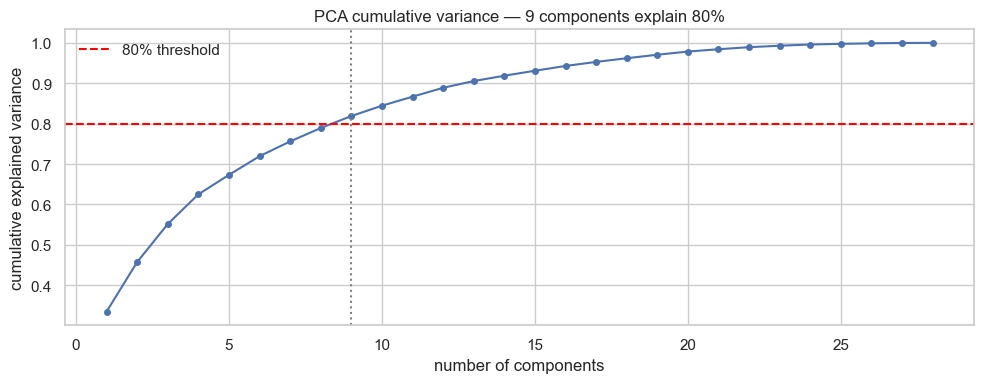

PC1 explains 33.5% of total variance

=== Top 20 most vulnerable communes:


,rank,libelle_commune,vulnerability_score
0,1,Vénissieux,22.973175
1,2,Vaulx-en-Velin,21.280160
2,3,Saint-Fons,19.730350
3,4,Givors,16.584924
4,5,Villefranche-sur-Saône,9.512540
5,6,Rillieux-la-Pape,8.826729
6,7,Villeurbanne,8.030694
7,8,Tarare,7.451136
8,9,Bron,5.997990
9,10,Thizy,4.912123



=== Top 15 feature loadings on PC1 (positive = drives vulnerability up):


,loading
fil_pct_prestations_sociales,0.307
fil_taux_pauvrete_ensemble,0.297
fil_taux_pauvrete_30_39ans,0.276
fil_taux_pauvrete_proprietaires,0.276
fil_taux_pauvrete_50_59ans,0.274
fil_taux_pauvrete_60_74ans,0.266
Trafic de stupéfiants,0.245
fil_taux_pauvrete_moins_30ans,0.239
fil_taux_pauvrete_75ans_plus,0.226
Vols violents sans arme,0.191


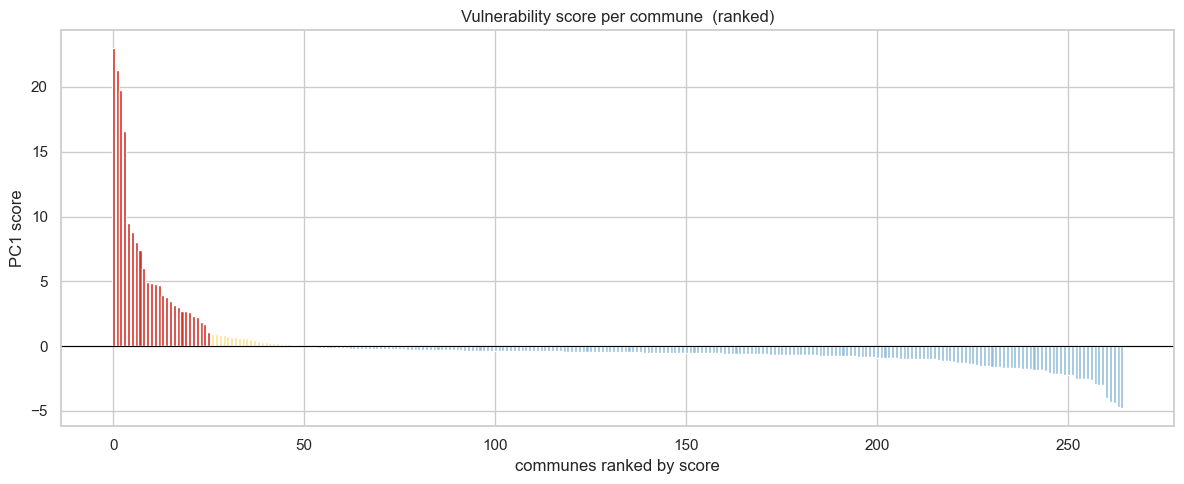


Saved: vulnerability_scores.csv


In [47]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n80    = int(np.searchsorted(cumvar, 0.80)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, marker="o", markersize=4)
ax.axhline(0.80, color="red", linestyle="--", label="80% threshold")
ax.axvline(n80, color="gray", linestyle=":")
ax.set_title(f"PCA cumulative variance — {n80} components explain 80%")
ax.set_xlabel("number of components")
ax.set_ylabel("cumulative explained variance")
ax.legend()
plt.tight_layout()
plt.show()

# PC1 alone is the vulnerability axis — high loading = high risk
pca1   = PCA(n_components=1, random_state=42)
pc1    = pca1.fit_transform(X_scaled).flatten()

# Flip sign if needed so that higher score = more vulnerable
loadings = pd.Series(pca1.components_[0], index=X_features.columns)
# Poverty features should have positive loadings on a vulnerability axis
poverty_features = [c for c in X_features.columns if "pauvrete" in c or "prestations" in c]
if loadings[poverty_features].mean() < 0:
    pc1 = -pc1

# dim_commune can have duplicate id_commune — keep only first occurrence
dim_commune_unique = dim_commune[["id_commune","libelle_commune"]].drop_duplicates(subset="id_commune")

vuln_df = (
    X_features.reset_index()[["id_commune"]]
    .assign(vulnerability_score=pc1)   # assign BEFORE merge — length matches X_features
    .merge(dim_commune_unique, on="id_commune", how="left")
    .sort_values("vulnerability_score", ascending=False)
    .reset_index(drop=True)
)
vuln_df["rank"] = vuln_df.index + 1

print(f"PC1 explains {pca1.explained_variance_ratio_[0]:.1%} of total variance")
print()
print("=== Top 20 most vulnerable communes:")
display(vuln_df.head(20)[["rank","libelle_commune","vulnerability_score"]])

print()
print("=== Top 15 feature loadings on PC1 (positive = drives vulnerability up):")
display(loadings.sort_values(ascending=False).head(15).round(3).to_frame("loading"))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(vuln_df)), vuln_df["vulnerability_score"],
       color=["#d73027" if v > 1 else "#fee090" if v > 0 else "#91bfdb"
              for v in vuln_df["vulnerability_score"]])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Vulnerability score per commune  (ranked)")
ax.set_xlabel("communes ranked by score")
ax.set_ylabel("PC1 score")
plt.tight_layout()
plt.show()

vuln_df.to_csv(OUTPUT_DIR / "vulnerability_scores.csv", index=False)
print("\nSaved: vulnerability_scores.csv")


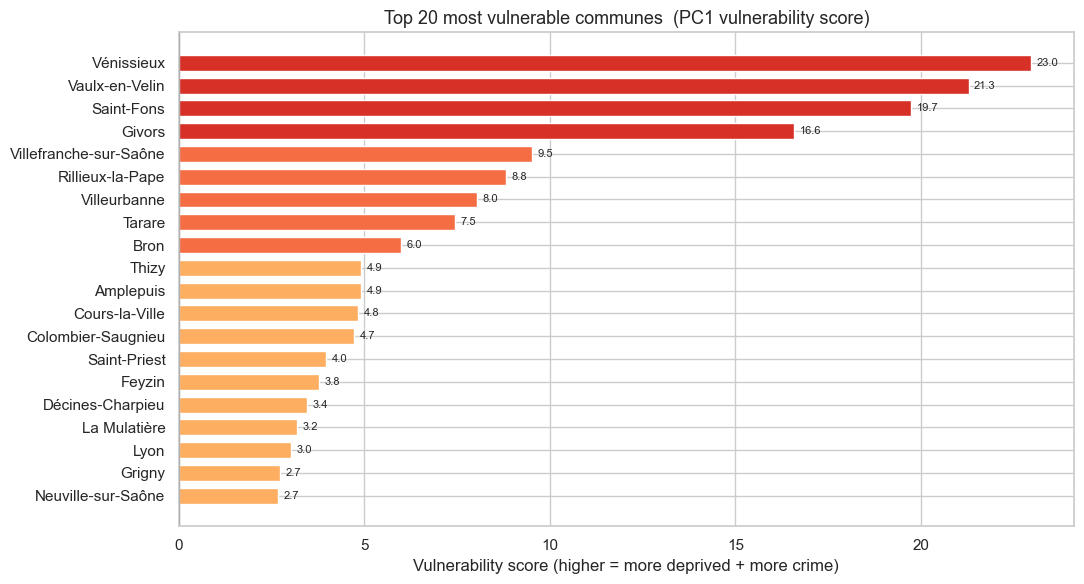

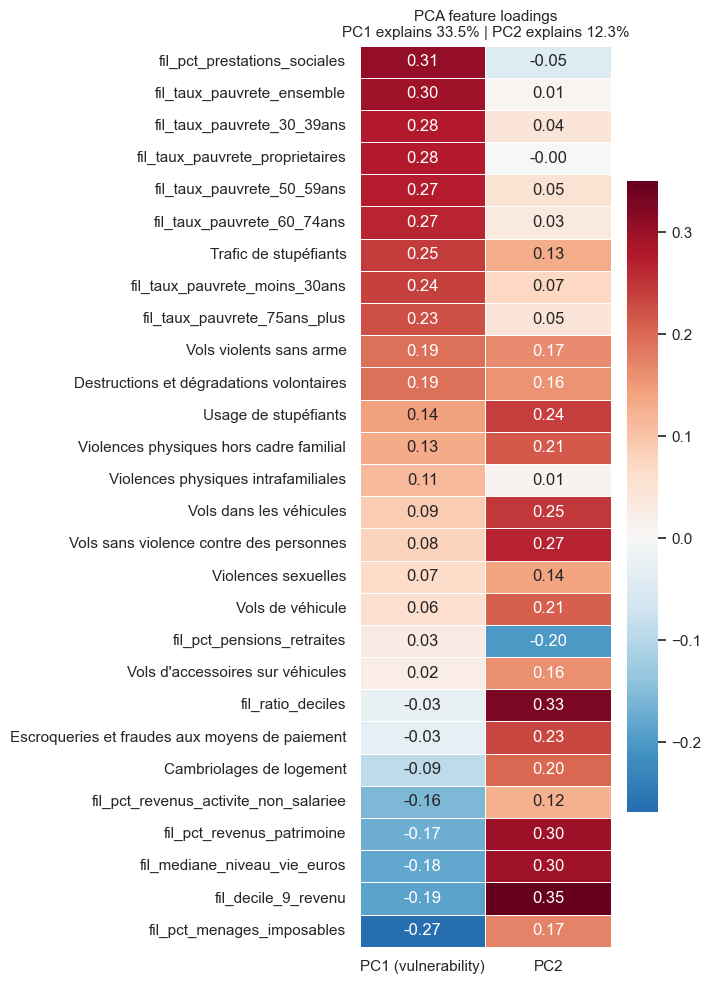

In [48]:
# ── VIZ 1a : Top-20 most vulnerable communes (labeled) ─────────────────────
top20 = vuln_df.head(20).copy()

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#d73027" if v > 10 else "#f46d43" if v > 5 else "#fdae61"
          for v in top20["vulnerability_score"]]
bars = ax.barh(top20["libelle_commune"][::-1], top20["vulnerability_score"][::-1],
               color=colors[::-1], edgecolor="white", height=0.7)
for bar, val in zip(bars, top20["vulnerability_score"][::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=8)
ax.set_title("Top 20 most vulnerable communes  (PC1 vulnerability score)", fontsize=13)
ax.set_xlabel("Vulnerability score (higher = more deprived + more crime)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

# ── VIZ 1b : PC1 & PC2 feature loadings heatmap ────────────────────────────
pca2   = PCA(n_components=2, random_state=42)
pca2.fit(X_scaled)
loadings2 = pd.DataFrame(
    pca2.components_.T,
    index=X_features.columns,
    columns=["PC1 (vulnerability)", "PC2"]
).sort_values("PC1 (vulnerability)", ascending=False)

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(loadings2, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.4, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title(f"PCA feature loadings\nPC1 explains {pca2.explained_variance_ratio_[0]:.1%} | "
             f"PC2 explains {pca2.explained_variance_ratio_[1]:.1%}", fontsize=11)
plt.tight_layout()
plt.show()

## 2. Abstention regression — predict `pct_abs_ins`

Using election: 2022_T1
id_election  annee_election  tour
    2022_T1            2022     1

Participation rows: 267
Abstention rate stats:
count    267.00
mean      18.65
std        4.37
min        5.34
25%       15.78
50%       17.83
75%       20.66
max       40.45
Name: pct_abs_ins, dtype: float64


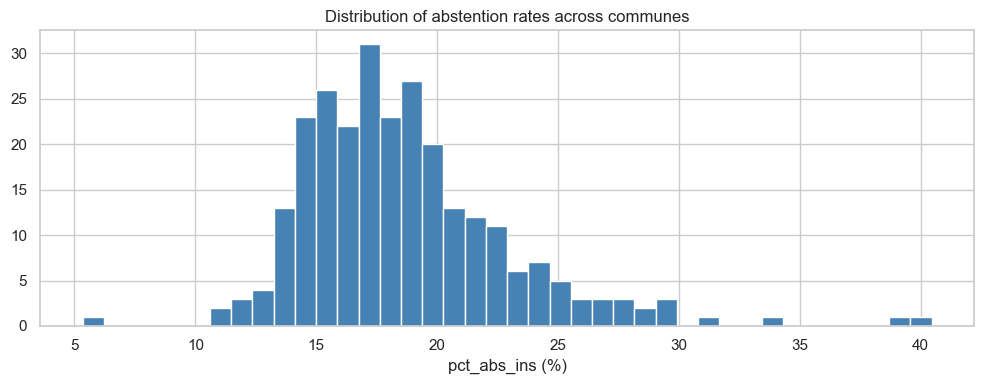

In [49]:
# Use the most recent presidential election tour 1 (highest coverage)
# Fall back to most recent available election if not present
latest_election = (
    dim_election.sort_values(["annee_election","tour"], ascending=[False,True])
    .iloc[0]["id_election"]
)
print("Using election:", latest_election)
print(dim_election[dim_election["id_election"]==latest_election].to_string(index=False))

particip = fact_particip[fact_particip["id_election"] == latest_election].copy()
particip["id_commune"] = norm_id(particip["id_commune"])
particip["pct_abs_ins"] = pd.to_numeric(particip["pct_abs_ins"], errors="coerce")

print(f"\nParticipation rows: {len(particip)}")
print(f"Abstention rate stats:\n{particip['pct_abs_ins'].describe().round(2)}")

fig, ax = plt.subplots(figsize=(10, 4))
particip["pct_abs_ins"].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Distribution of abstention rates across communes")
ax.set_xlabel("pct_abs_ins (%)")
plt.tight_layout()
plt.show()


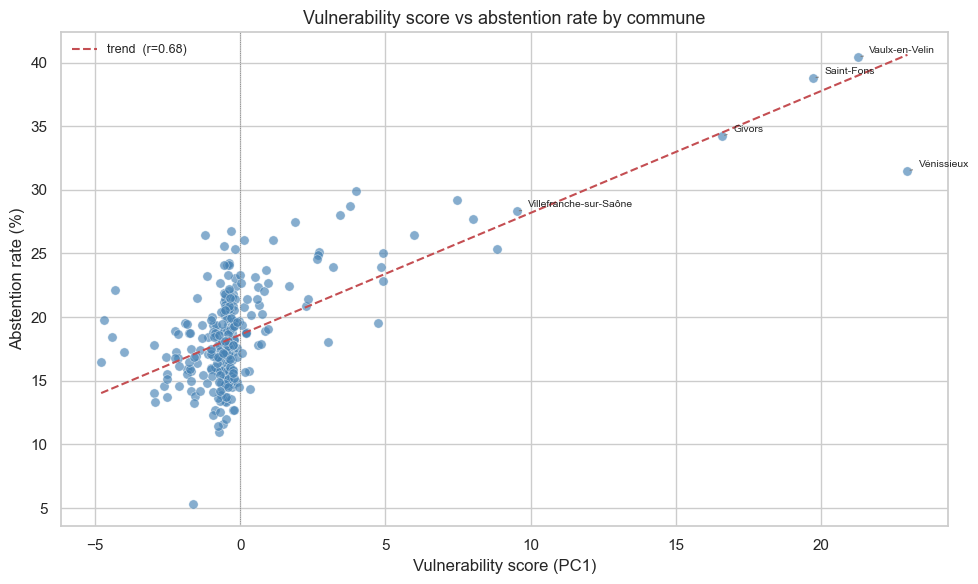

Pearson correlation (vulnerability ↔ abstention): 0.678


In [50]:
# ── VIZ 2 : Vulnerability score vs abstention rate ──────────────────────────
scatter_df = (
    X_features.reset_index()[["id_commune"]]
    .assign(vulnerability_score=pc1)
    .merge(particip[["id_commune", "pct_abs_ins"]], on="id_commune", how="inner")
    .merge(dim_commune_unique, on="id_commune", how="left")
    .dropna(subset=["pct_abs_ins"])
)

corr = scatter_df[["vulnerability_score", "pct_abs_ins"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(scatter_df["vulnerability_score"], scatter_df["pct_abs_ins"],
                alpha=0.65, s=45, color="steelblue", edgecolors="white", linewidths=0.4)

# Annotate the top-5 most vulnerable
top5 = scatter_df.nlargest(5, "vulnerability_score")
for _, row in top5.iterrows():
    ax.annotate(row["libelle_commune"],
                xy=(row["vulnerability_score"], row["pct_abs_ins"]),
                xytext=(8, 3), textcoords="offset points", fontsize=7.5,
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.8))

# Trend line
m, b = np.polyfit(scatter_df["vulnerability_score"], scatter_df["pct_abs_ins"], 1)
x_line = np.linspace(scatter_df["vulnerability_score"].min(),
                     scatter_df["vulnerability_score"].max(), 100)
ax.plot(x_line, m * x_line + b, "r--", linewidth=1.5, label=f"trend  (r={corr:.2f})")
ax.axvline(0, color="gray", linewidth=0.6, linestyle=":")

ax.set_title("Vulnerability score vs abstention rate by commune", fontsize=13)
ax.set_xlabel("Vulnerability score (PC1)")
ax.set_ylabel("Abstention rate (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"Pearson correlation (vulnerability ↔ abstention): {corr:.3f}")

In [51]:
# Merge features with target
reg_df = (
    X_features.reset_index()
    .merge(particip[["id_commune","pct_abs_ins"]], on="id_commune", how="inner")
    .dropna(subset=["pct_abs_ins"])
)

print(f"Communes with both features and abstention data: {len(reg_df)}")

feature_cols = X_features.columns.tolist()
X_reg = reg_df[feature_cols].values
y_reg = reg_df["pct_abs_ins"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale
sc_reg  = StandardScaler()
Xtr_reg = sc_reg.fit_transform(X_train)
Xte_reg = sc_reg.transform(X_test)

# Model
gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=3, subsample=0.8, random_state=42
)
gbr.fit(Xtr_reg, y_train)
y_pred = gbr.predict(Xte_reg)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"\n=== Test set performance ===")
print(f"  MAE : {mae:.2f} percentage points")
print(f"  R²  : {r2:.3f}")

# Cross-validation
cv_r2 = cross_val_score(
    Pipeline([("sc", StandardScaler()),
              ("gbr", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                max_depth=3, subsample=0.8, random_state=42))]),
    X_reg, y_reg, cv=5, scoring="r2"
)
print(f"  5-fold CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print()
print("Interpretation: R² of 0.5 means the model explains 50% of the variance")
print("in abstention rates across communes using only socioeconomic + security features.")


Communes with both features and abstention data: 265

=== Test set performance ===
  MAE : 2.11 percentage points
  R²  : 0.555
  5-fold CV R²: 0.482 ± 0.151

Interpretation: R² of 0.5 means the model explains 50% of the variance
in abstention rates across communes using only socioeconomic + security features.


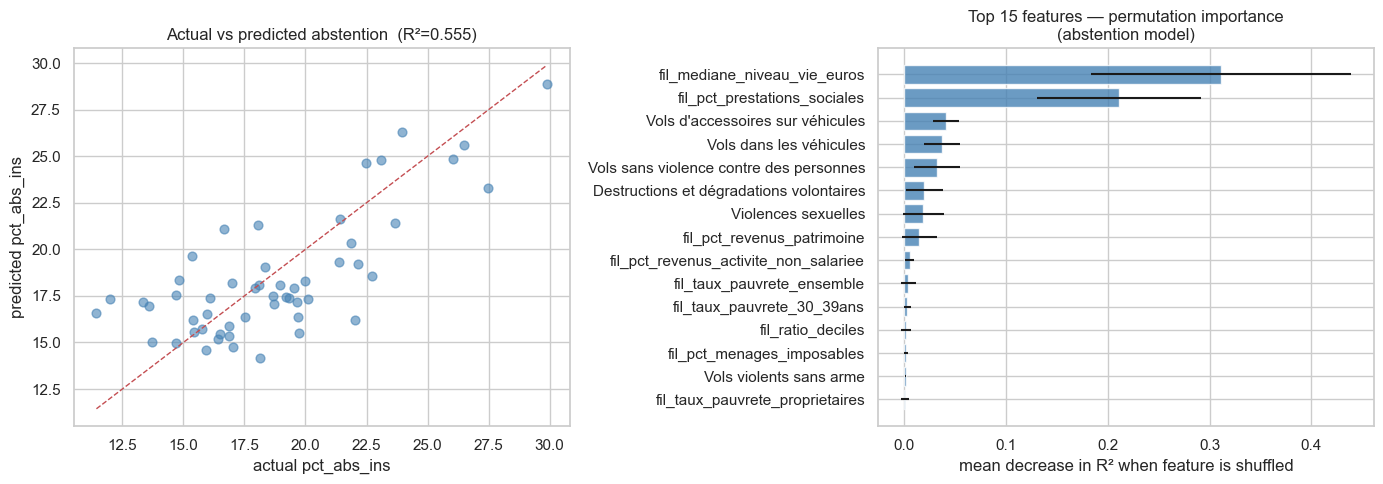

=== Top 15 features driving abstention prediction:


,feature,importance,std
0,fil_mediane_niveau_vie_euros,0.311454,0.127884
1,fil_pct_prestations_sociales,0.210814,0.080908
2,Vols d'accessoires sur véhicules,0.040651,0.012796
3,Vols dans les véhicules,0.037131,0.017628
4,Vols sans violence contre des personnes,0.031975,0.022337
5,Destructions et dégradations volontaires,0.019646,0.018080
6,Violences sexuelles,0.018802,0.020147
7,fil_pct_revenus_patrimoine,0.014563,0.017309
8,fil_pct_revenus_activite_non_salariee,0.005222,0.004709
9,fil_taux_pauvrete_ensemble,0.003860,0.007206



Saved: abstention_predictions.csv


In [52]:
# Actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.6, color="steelblue", s=40)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_title(f"Actual vs predicted abstention  (R²={r2:.3f})")
axes[0].set_xlabel("actual pct_abs_ins")
axes[0].set_ylabel("predicted pct_abs_ins")

# Feature importance
perm_imp = permutation_importance(gbr, Xte_reg, y_test, n_repeats=20, random_state=42)
imp_df = (
    pd.DataFrame({"feature": feature_cols,
                  "importance": perm_imp.importances_mean,
                  "std": perm_imp.importances_std})
    .sort_values("importance", ascending=False).head(15)
)

axes[1].barh(imp_df["feature"][::-1], imp_df["importance"][::-1],
             xerr=imp_df["std"][::-1], color="steelblue", alpha=0.8)
axes[1].set_title("Top 15 features — permutation importance\n(abstention model)")
axes[1].set_xlabel("mean decrease in R² when feature is shuffled")

plt.tight_layout()
plt.show()

print("=== Top 15 features driving abstention prediction:")
display(imp_df[["feature","importance","std"]].reset_index(drop=True))

# Save predictions
reg_df["predicted_abstention"] = Pipeline([
    ("sc", StandardScaler()),
    ("gbr", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                       max_depth=3, subsample=0.8, random_state=42))
]).fit(X_reg, y_reg).predict(
    StandardScaler().fit_transform(X_reg)
)
reg_df[["id_commune","pct_abs_ins","predicted_abstention"]].to_csv(
    OUTPUT_DIR / "abstention_predictions.csv", index=False)
print("\nSaved: abstention_predictions.csv")


## 3. Dominant political nuance classification

In [53]:
# Build dominant nuance per commune for the chosen election
resultats = fact_resultats[fact_resultats["id_election"] == latest_election].copy()
resultats["id_commune"] = norm_id(resultats["id_commune"])
resultats["pct_voix_exprimes"] = pd.to_numeric(resultats["pct_voix_exprimes"], errors="coerce")

# Dominant nuance = nuance with highest pct_voix_exprimes per commune
dominant = (
    resultats.sort_values("pct_voix_exprimes", ascending=False)
    .drop_duplicates(subset="id_commune", keep="first")
    [["id_commune","id_nuance","pct_voix_exprimes"]]
    .merge(dim_nuance, on="id_nuance", how="left")
)

print("Dominant nuance distribution:")
display(dominant["libelle_nuance"].value_counts().to_frame("n_communes"))

# Keep only nuances with >= 5 communes (too few = unreliable class)
min_communes = 5
nuance_counts = dominant["libelle_nuance"].value_counts()
valid_nuances = nuance_counts[nuance_counts >= min_communes].index
dominant = dominant[dominant["libelle_nuance"].isin(valid_nuances)]
print(f"\nKept {dominant['libelle_nuance'].nunique()} nuances with >= {min_communes} communes")


Dominant nuance distribution:


,n_communes
libelle_nuance,
La République en marche,184
Front National,68
La France insoumise,15



Kept 3 nuances with >= 5 communes


In [54]:
clf_df = (
    X_features.reset_index()
    .merge(dominant[["id_commune","libelle_nuance"]], on="id_commune", how="inner")
    .dropna(subset=["libelle_nuance"])
)

print(f"Communes with both features and nuance label: {len(clf_df)}")

X_clf = clf_df[feature_cols].values
le    = LabelEncoder()
y_clf = le.fit_transform(clf_df["libelle_nuance"])

print(f"Classes: {list(le.classes_)}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
    if clf_df["libelle_nuance"].value_counts().min() >= 2 else None
)

sc_clf = StandardScaler()
Xtr_c  = sc_clf.fit_transform(X_tr)
Xte_c  = sc_clf.transform(X_te)

rf = RandomForestClassifier(
    n_estimators=500, max_depth=6,
    min_samples_leaf=3, random_state=42, class_weight="balanced"
)
rf.fit(Xtr_c, y_tr)
y_pred_c = rf.predict(Xte_c)

print("\n=== Classification report:")
print(classification_report(y_te, y_pred_c, target_names=le.classes_, zero_division=0))

cv_acc = cross_val_score(
    Pipeline([("sc", StandardScaler()),
              ("rf", RandomForestClassifier(n_estimators=500, max_depth=6,
                                            min_samples_leaf=3, random_state=42,
                                            class_weight="balanced"))]),
    X_clf, y_clf, cv=5, scoring="accuracy"
)
print(f"5-fold CV accuracy: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
print()
print("Baseline (majority class):",
      round(pd.Series(y_clf).value_counts(normalize=True).max(), 3))
print("If CV accuracy > baseline, the model is learning something real.")


Communes with both features and nuance label: 265
Classes: ['Front National', 'La France insoumise', 'La République en marche']

=== Classification report:
                         precision    recall  f1-score   support

         Front National       0.55      0.92      0.69        13
    La France insoumise       0.67      0.67      0.67         3
La République en marche       0.93      0.70      0.80        37

               accuracy                           0.75        53
              macro avg       0.71      0.76      0.72        53
           weighted avg       0.82      0.75      0.76        53

5-fold CV accuracy: 0.740 ± 0.022

Baseline (majority class): 0.691
If CV accuracy > baseline, the model is learning something real.


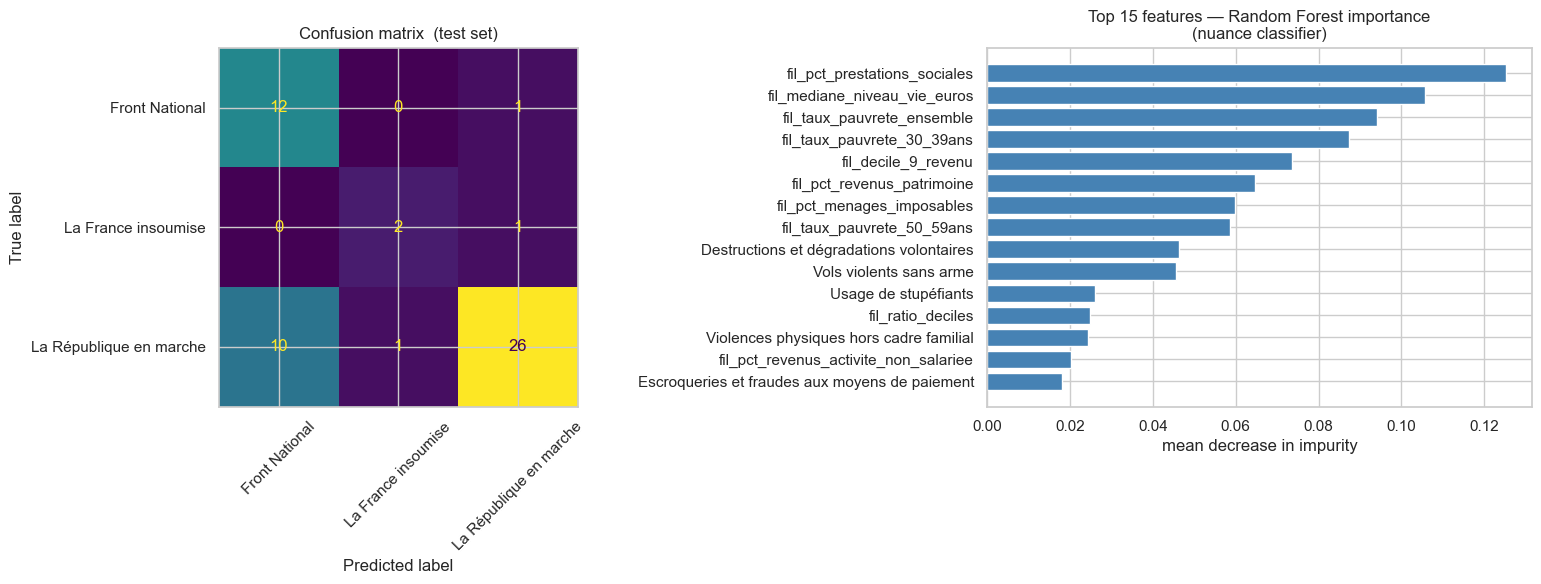

=== Top 15 features for predicting political nuance:


,feature,importance
0,fil_pct_prestations_sociales,0.125256
1,fil_mediane_niveau_vie_euros,0.105618
2,fil_taux_pauvrete_ensemble,0.094002
3,fil_taux_pauvrete_30_39ans,0.087435
4,fil_decile_9_revenu,0.073529
5,fil_pct_revenus_patrimoine,0.064775
6,fil_pct_menages_imposables,0.059769
7,fil_taux_pauvrete_50_59ans,0.058531
8,Destructions et dégradations volontaires,0.046388
9,Vols violents sans arme,0.045482



Saved: nuance_predictions.csv


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_c, display_labels=le.classes_,
    ax=axes[0], colorbar=False, xticks_rotation=45
)
axes[0].set_title("Confusion matrix  (test set)")

# Feature importance
fi_df = (
    pd.DataFrame({"feature": feature_cols,
                  "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False).head(15)
)
axes[1].barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="steelblue")
axes[1].set_title("Top 15 features — Random Forest importance\n(nuance classifier)")
axes[1].set_xlabel("mean decrease in impurity")

plt.tight_layout()
plt.show()

print("=== Top 15 features for predicting political nuance:")
display(fi_df.reset_index(drop=True))

# Save predictions
clf_df["predicted_nuance"] = le.inverse_transform(
    RandomForestClassifier(n_estimators=500, max_depth=6,
                           min_samples_leaf=3, random_state=42, class_weight="balanced")
    .fit(sc_clf.fit_transform(X_clf), y_clf)
    .predict(sc_clf.transform(X_clf))
)
clf_df[["id_commune","libelle_nuance","predicted_nuance"]].to_csv(
    OUTPUT_DIR / "nuance_predictions.csv", index=False)
print("\nSaved: nuance_predictions.csv")


## 4. Combined commune profile

In [56]:
# Merge all outputs into one summary table per commune
combined = (
    dim_commune[["id_commune","libelle_commune"]]
    .merge(vuln_df[["id_commune","vulnerability_score","rank"]], on="id_commune", how="left")
    .merge(reg_df[["id_commune","pct_abs_ins","predicted_abstention"]],
           on="id_commune", how="left")
    .merge(clf_df[["id_commune","libelle_nuance","predicted_nuance"]],
           on="id_commune", how="left")
    .sort_values("vulnerability_score", ascending=False, na_position="last")
)

print(f"Combined profile: {combined.shape}")
display(combined.head(20))

combined.to_csv(OUTPUT_DIR / "commune_profiles.csv", index=False)
print("\nSaved: commune_profiles.csv")
print()
print("=== Summary of what each column means:")
print("  vulnerability_score  : PC1 composite index. Higher = more deprived + more crime.")
print("  rank                 : 1 = most vulnerable commune in the dataset.")
print("  pct_abs_ins          : actual abstention rate from election data.")
print("  predicted_abstention : GBR model prediction of abstention.")
print("  libelle_nuance       : actual dominant political nuance.")
print("  predicted_nuance     : RF model prediction of dominant nuance.")


Combined profile: (305, 8)


,id_commune,libelle_commune,vulnerability_score,rank,pct_abs_ins,predicted_abstention,libelle_nuance,predicted_nuance
174,69259,Vénissieux,22.973175,1.0,31.50,29.625821,La France insoumise,La France insoumise
171,69256,Vaulx-en-Velin,21.280160,2.0,40.45,29.652783,La France insoumise,La France insoumise
109,69199,Saint-Fons,19.730350,3.0,38.78,28.531481,La France insoumise,La France insoumise
284,69091,Givors,16.584924,4.0,34.24,29.590486,La France insoumise,La France insoumise
179,69264,Villefranche-sur-Saône,9.512540,5.0,28.34,23.454079,La France insoumise,La France insoumise
202,69286,Rillieux-la-Pape,8.826729,6.0,25.34,21.117056,La France insoumise,La France insoumise
181,69266,Villeurbanne,8.030694,7.0,27.71,23.478085,La France insoumise,La France insoumise
157,69243,Tarare,7.451136,8.0,29.24,24.699258,La République en marche,La France insoumise
206,69029,Bron,5.997990,9.0,26.48,24.507152,La France insoumise,La France insoumise
300,69248,Thizy-Les-Bourgs,4.912123,10.0,25.07,21.507844,Front National,Front National



Saved: commune_profiles.csv

=== Summary of what each column means:
  vulnerability_score  : PC1 composite index. Higher = more deprived + more crime.
  rank                 : 1 = most vulnerable commune in the dataset.
  pct_abs_ins          : actual abstention rate from election data.
  predicted_abstention : GBR model prediction of abstention.
  libelle_nuance       : actual dominant political nuance.
  predicted_nuance     : RF model prediction of dominant nuance.
